# Réplica del paper con variables completas

Este notebook replica el flujo central del paper usando las variables completas del dataset UCI:

- división estratificada 70/30,
- escalado con `StandardScaler`,
- selección de 32 variables con ANOVA F-score,
- benchmark de cinco modelos,
- replay determinista del mejor experimento `SMOTE + Optuna` sobre `Gradient Boosting`.

El objetivo de esta pieza no es proponer un uso clínico directo, sino mostrar capacidad de reproducción metodológica y comparación experimental.

/home/rosewt-dell/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Réplica del paper con variables completas
Dataset cargado con dimensiones: (319, 39)
Conjunto de entrenamiento: (223, 32)
Conjunto de prueba: (96, 32)
Variables de entrada utilizadas: 32
Selección ANOVA aplicada: 32 variables
Evaluando Logistic Regression...


Evaluando Random Forest...


Evaluando Gradient Boosting...


Evaluando XGBoost...


...


Resultados del benchmark:


,Modelo,Test Accuracy,Test AUC,Mejores Parámetros
0,XGBoost,0.854167,0.901476,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,Logistic Regression,0.833333,0.888455,{'C': 10}
2,Gradient Boosting,0.812500,0.893663,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti..."
3,CatBoost,0.812500,0.907986,"{'depth': 4, 'iterations': 200, 'learning_rate..."
4,Random Forest,0.791667,0.900608,"{'max_depth': 10, 'n_estimators': 200}"



Resumen comparativo final:


,Estrategia,Test Accuracy,Test AUC
0,Mejor benchmark (XGBoost),0.854167,0.901476
1,GB Optimizado (SMOTE + Optuna),0.885417,0.927951



Reporte de clasificación del modelo optimizado:
                  precision    recall  f1-score   support

        Sano (0)       0.89      0.88      0.88        48
Con cálculos (1)       0.88      0.90      0.89        48

        accuracy                           0.89        96
       macro avg       0.89      0.89      0.89        96
    weighted avg       0.89      0.89      0.89        96

Hiperparámetros fijados para replay determinista del mejor estudio Optuna original:
{'n_estimators': 894, 'learning_rate': 0.2975045700161574, 'max_depth': 4, 'min_samples_leaf': 19, 'subsample': 0.7139837324629363}


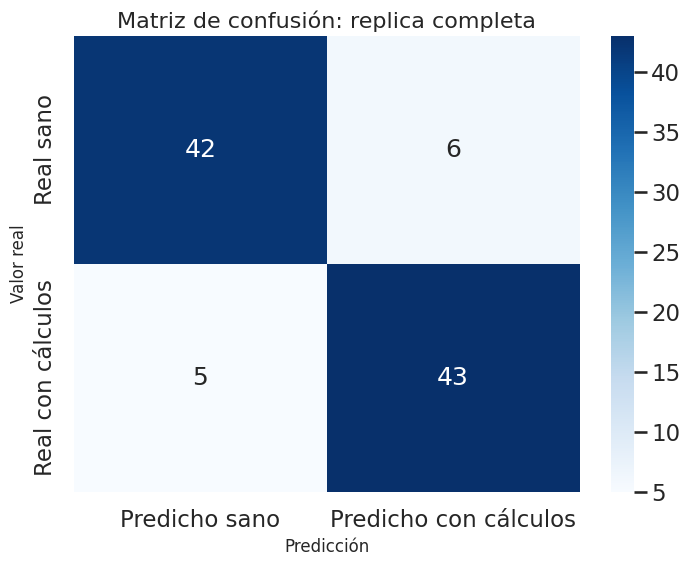

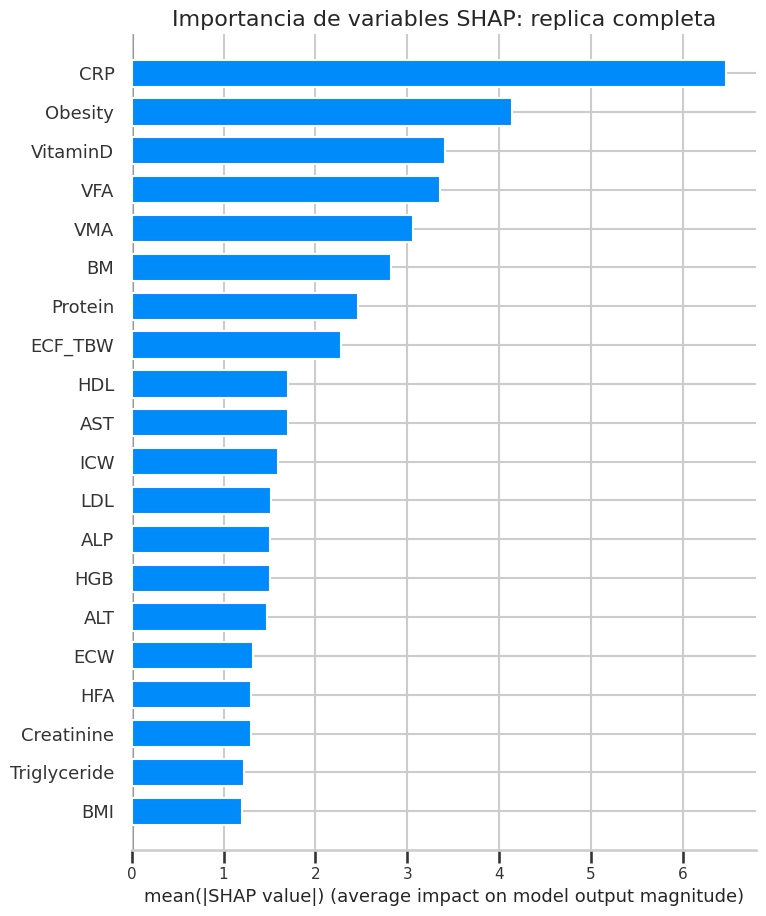

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(ROOT / "scripts"))

from portfolio_pipeline import run_full_experiment

DATA_PATH = ROOT / "data" / "dataset-uci.xlsx"
REPORT_PATH = ROOT / "figures" / "replica_metrics.json"

results = run_full_experiment(DATA_PATH, report_path=REPORT_PATH)

In [2]:
print("Variables seleccionadas por ANOVA:")
for feature in results["selected_features"]:
    print("-", feature)

Variables seleccionadas por ANOVA:
- Gender
- CAD
- Hypothyroidism
- Hyperlipidemia
- DM
- Height
- BMI
- TBW
- ECW
- ICW
- ECF_TBW
- TBFR
- LM
- Protein
- BM
- MM
- Obesity
- TFC
- VFA
- VMA
- HFA
- TC
- LDL
- HDL
- Triglyceride
- AST
- ALT
- ALP
- Creatinine
- CRP
- HGB
- VitaminD
